In [1]:
import sys, os, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

sys.path.append("../src")
from dataset import gather_samples, stratified_split, RiceLeafDataset, CLASSES

os.makedirs("../figures", exist_ok=True)
os.makedirs("../tables", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, CLASSES)

cuda ['Healthy', 'Insect', 'Leaf Scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']


In [2]:
samples = gather_samples()
train_s, val_s, test_s = stratified_split(samples)
test_set = RiceLeafDataset(test_s, split='test')
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=2)
print(len(samples), len(train_s), len(val_s), len(test_set))

2753 1927 413 413


In [3]:
def build_model(name, n=7):
    if name == "resnet50":
        m = models.resnet50(weights=None); m.fc = nn.Linear(m.fc.in_features, n)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None); m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)
    elif name == "mobilenetv3_large":
        m = models.mobilenet_v3_large(weights=None); m.classifier[3] = nn.Linear(m.classifier[3].in_features, n)
    elif name == "convnext_tiny":
        m = models.convnext_tiny(weights=None); m.classifier[2] = nn.Linear(m.classifier[2].in_features, n)
    elif name == "swin_tiny":
        m = models.swin_t(weights=None); m.head = nn.Linear(m.head.in_features, n)
    return m

NAMES = {"resnet50": "ResNet50", "efficientnet_b0": "EfficientNet-B0",
         "mobilenetv3_large": "MobileNetV3-Large", "convnext_tiny": "ConvNeXt-Tiny",
         "swin_tiny": "Swin-Tiny"}

@torch.no_grad()
def predict(model):
    model.eval(); ys, ps = [], []
    for x, y in test_loader:
        ps.append(model(x.to(device)).argmax(1).cpu().numpy()); ys.append(np.asarray(y))
    return np.concatenate(ys), np.concatenate(ps)

preds, rows = {}, []
for key, disp in NAMES.items():
    m = build_model(key)
    m.load_state_dict(torch.load(f"../notebooks/{key}_best.pth", map_location="cpu"))
    m.to(device)
    y, p = predict(m)
    preds[key] = (y, p)
    rows.append({"Model": disp,
                 "Params (M)": round(sum(q.numel() for q in m.parameters())/1e6, 2),
                 "Accuracy": round(accuracy_score(y, p), 4),
                 "Macro-F1": round(f1_score(y, p, average="macro"), 4)})
    del m; torch.cuda.empty_cache()

comp = pd.DataFrame(rows)
inf_ms = {"ResNet50": np.nan, "EfficientNet-B0": 8.44, "MobileNetV3-Large": 7.60,
          "ConvNeXt-Tiny": 9.63, "Swin-Tiny": 12.90}
comp["Inference (ms)"] = comp["Model"].map(inf_ms)
print(comp)

y, p = preds["convnext_tiny"]
print(classification_report(y, p, target_names=CLASSES, digits=3))

               Model  Params (M)  Accuracy  Macro-F1  Inference (ms)
0           ResNet50       23.52    0.7627    0.7346             NaN
1    EfficientNet-B0        4.02    0.7918    0.7483            8.44
2  MobileNetV3-Large        4.21    0.7530    0.7234            7.60
3      ConvNeXt-Tiny       27.83    0.7676    0.7215            9.63
4          Swin-Tiny       27.52    0.7918    0.7682           12.90
                 precision    recall  f1-score   support

        Healthy      0.840     0.878     0.859        90
         Insect      0.810     0.810     0.810        42
     Leaf Scald      0.745     0.651     0.695        63
     Rice Blast      0.939     0.886     0.912       105
Rice Leaffolder      0.667     0.757     0.709        37
   Rice Stripes      0.459     0.425     0.442        40
    Rice Tungro      0.568     0.694     0.625        36

       accuracy                          0.768       413
      macro avg      0.718     0.729     0.721       413
   weighted av

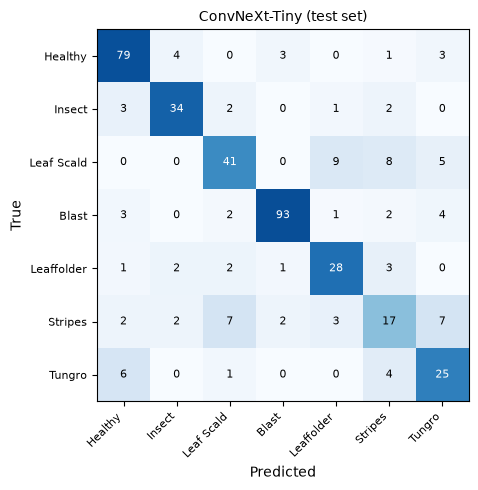

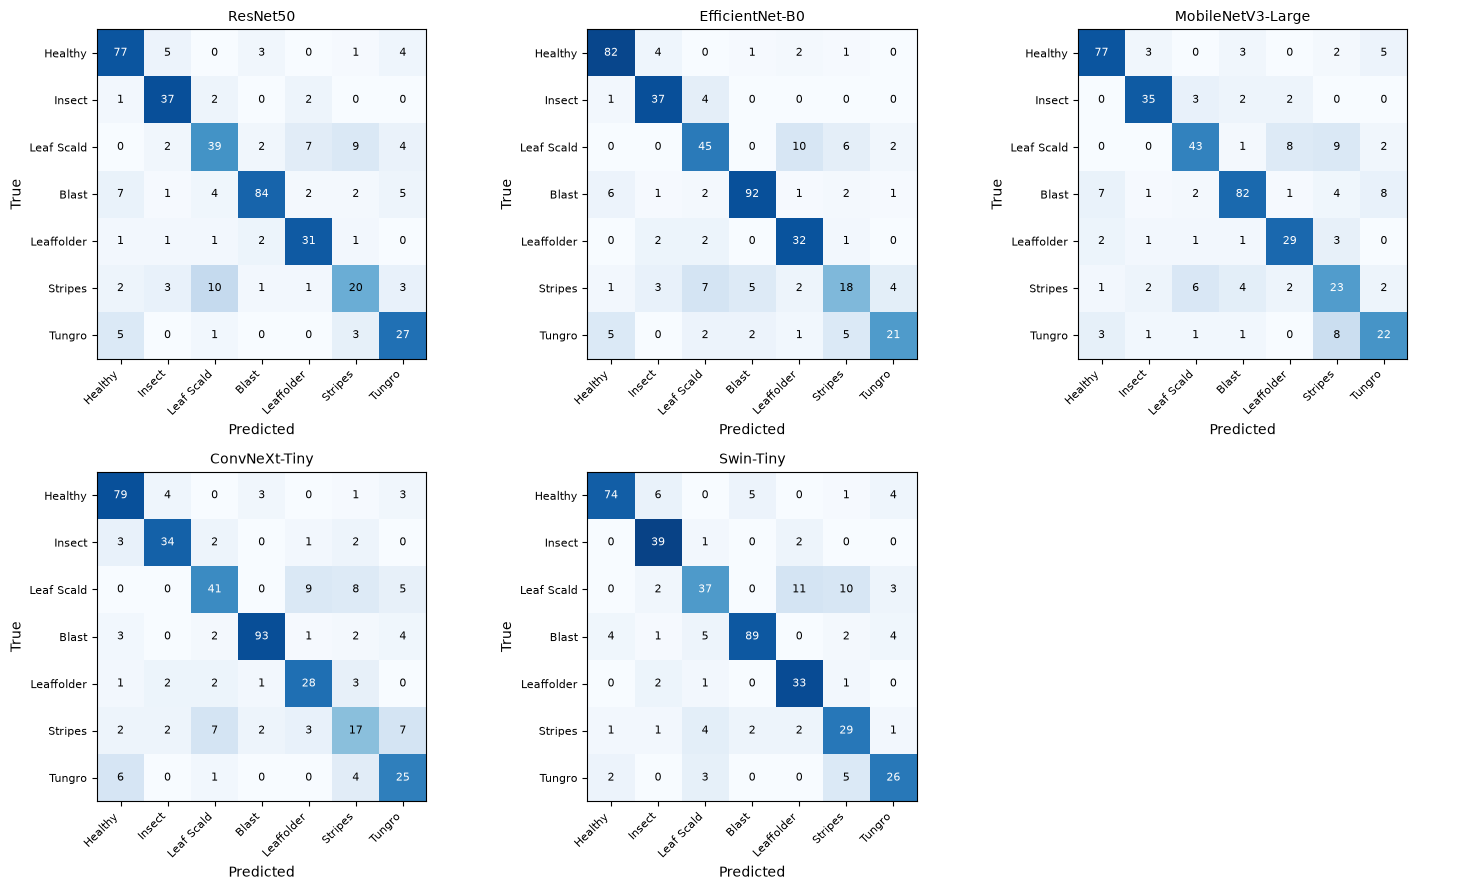

In [4]:
short = [c.replace("Rice ", "") for c in CLASSES]

def draw_cm(ax, y, p, title):
    cm = confusion_matrix(y, p, labels=range(len(CLASSES)))
    cmn = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short, fontsize=8)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cmn[i, j] > 0.5 else "black")
    ax.set_title(title, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

fig, ax = plt.subplots(figsize=(5.5, 5))
draw_cm(ax, *preds["convnext_tiny"], "ConvNeXt-Tiny (test set)")
plt.tight_layout(); plt.savefig("../figures/cm_convnext_tiny.png", dpi=300); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (key, disp) in zip(axes.ravel(), NAMES.items()):
    draw_cm(ax, *preds[key], disp)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.savefig("../figures/cm_all_models.png", dpi=300); plt.show()

In [5]:
def save_table(df, name):
    df.to_csv(f"../tables/{name}.csv", index=False)
    try:
        with open(f"../tables/{name}.tex", "w") as f:
            f.write(df.to_latex(index=False, na_rep="--", float_format="%.4f"))
    except Exception as e:
        print("LaTeX skip:", e)

# Model comparison
save_table(comp, "model_comparison")

# 5-fold CV
fold_f1 = [0.7761, 0.7876, 0.7345, 0.7803, 0.7221]
cv_fold = pd.DataFrame({"Fold": [1, 2, 3, 4, 5], "Macro-F1": fold_f1})
print(f"Macro-F1 mean={np.mean(fold_f1):.4f}, std(ddof=1)={np.std(fold_f1, ddof=1):.4f}")
print(f"Acc 0.7820 +- {0.0266*np.sqrt(5/4):.4f} (ddof=1, converted from population std)")
cv_cls = pd.DataFrame({"Class": ["Healthy", "Insect", "Leaf Scald", "Rice Blast",
                                 "Leaf-folder", "Rice Stripes", "Tungro"],
                       "Mean F1": [0.854, 0.862, 0.766, 0.836, 0.775, 0.604, 0.624]})
save_table(cv_fold, "cv_folds"); save_table(cv_cls, "cv_per_class")

# External test
ext = pd.DataFrame({
    "Dataset": ["RiceLeafBD (Blast+Tungro)", "Sethy (Healthy+Tungro)"],
    "7-way Acc": [0.083, 0.390],
    "Restricted Acc": [0.526, 0.849],
    "Balanced Acc": [0.51, 0.88],
    "Class recall (restricted)": ["Blast 0.83, Tungro 0.20", "Healthy 0.98, Tungro 0.79"]})
save_table(ext, "external_test")
print(cv_cls); print(ext)

Macro-F1 mean=0.7601, std(ddof=1)=0.0297
Acc 0.7820 +- 0.0297 (ddof=1, converted from population std)
          Class  Mean F1
0       Healthy    0.854
1        Insect    0.862
2    Leaf Scald    0.766
3    Rice Blast    0.836
4   Leaf-folder    0.775
5  Rice Stripes    0.604
6        Tungro    0.624
                     Dataset  7-way Acc  Restricted Acc  Balanced Acc  \
0  RiceLeafBD (Blast+Tungro)      0.083           0.526          0.51   
1     Sethy (Healthy+Tungro)      0.390           0.849          0.88   

   Class recall (restricted)  
0    Blast 0.83, Tungro 0.20  
1  Healthy 0.98, Tungro 0.79  


In [6]:
import glob, time, subprocess
for p in sorted(glob.glob("../notebooks/convnext*.pth")):
    print(p, time.ctime(os.path.getmtime(p)), os.path.getsize(p))

# কোন notebook কোন ফাইলে save করছে
print(subprocess.run("grep -n 'convnext.*\\.pth' ../notebooks/*.ipynb | cut -c1-200",
                     shell=True, capture_output=True, text=True).stdout)

# focal checkpoint এর test ফল (সঠিক হলে ~0.7398 আসার কথা)
m = build_model("convnext_tiny")
m.load_state_dict(torch.load("../notebooks/convnext_tiny_focal_best.pth", map_location="cpu")); m.to(device)
y, p = predict(m)
print("focal:", round(f1_score(y, p, average="macro"), 4), round(accuracy_score(y, p), 4))

../notebooks/convnext_tiny_best.pth Sun Sep 27 00:23:02 2026 111370791
../notebooks/convnext_tiny_focal_best.pth Mon Sep 28 18:54:46 2026 111371983
../notebooks/05_Training_ConvNeXt.ipynb:239:    "        torch.save(best_model_wts, \"convnext_tiny_best.pth\")\n",
../notebooks/05_Training_ConvNeXt_Focal.ipynb:412:    "        torch.save(best_model_wts, \"convnext_tiny_focal_best.pth\")\n",
../notebooks/07_GradCAM.ipynb:42:    "model.load_state_dict(torch.load(\"convnext_tiny_best.pth\", map_location=device))\n",
../notebooks/09_External_Test.ipynb:101:      "Loaded: convnext_tiny_best.pth\n",
../notebooks/09_External_Test.ipynb:133:    "CKPT = next(p for p in [\"convnext_tiny_best.pth\", \"../notebooks/convnext_tiny_best.pth\",\n",
../notebooks/09_External_Test.ipynb:134:    "                        \"../convnext_tiny_best.pth\"] if Path(p).exists())\n",
../notebooks/09_External_Test.ipynb:226:      "../notebooks/convnext_tiny_best.pth | OrderedDict | ['features.0.0.weight', 'features.0

In [7]:
import json
for nb in ["05_Training_ConvNeXt", "07_GradCAM", "09_External_Test"]:
    p = f"../notebooks/{nb}.ipynb"
    print("=====", nb, "| saved:", time.ctime(os.path.getmtime(p)))
    for i, c in enumerate(json.load(open(p))["cells"]):
        if c["cell_type"] != "code": continue
        txt = "".join("".join(o.get("text", [])) for o in c.get("outputs", []))
        for line in txt.splitlines():
            if any(k in line.lower() for k in ["macro", "accuracy", "test acc", "f1", "best val", "early"]):
                print(f"[cell {i}]", line[:150])

===== 05_Training_ConvNeXt | saved: Sun Sep 27 00:27:41 2026
[cell 7] Early stopping at epoch 12
[cell 7] Best val_loss: 0.792248679131053
[cell 9] Macro-F1: 0.7214740889813538
[cell 9]                  precision    recall  f1-score   support
[cell 9]        accuracy                           0.77       413
[cell 9]       macro avg       0.72      0.73      0.72       413
===== 07_GradCAM | saved: Mon Sep 28 19:25:16 2026
===== 09_External_Test | saved: Wed Sep 30 16:05:03 2026
[cell 2] 7-way accuracy       : 0.0833
[cell 2] restricted accuracy  : 0.5262  (শুধু ['Rice Blast', 'Rice Tungro'])
[cell 2] 7-way accuracy       : 0.3900
[cell 2] restricted accuracy  : 0.8491  (শুধু ['Healthy', 'Rice Tungro'])
